Exploratory Data Analysis (EDA)


In [61]:
%matplotlib inline

import numpy as np
import pandas as pd
sales=pd.read_csv('../data/sales.csv')
print("Dataset Head:")
display(sales.head(10))

Dataset Head:


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882
5,687329,674,2,2013-03-19,1016,1,1,0,0,8406
6,600327,659,7,2014-06-08,0,0,0,0,0,0
7,96265,27,3,2014-07-16,1106,1,1,0,1,11162
8,364435,347,6,2013-05-11,448,1,0,0,0,5559
9,163146,288,2,2013-06-25,291,1,0,0,0,3997


In [62]:
# What are the data types?
print("\nDataset Info:")
sales.info()
# 2. Inspect data types and non-null counts
print("\nDataset Info:")
sales.info()

# 3. Statistical summary of numeric features
print("\nSummary Statistics:")
display(sales.describe())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 48.9 MB

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


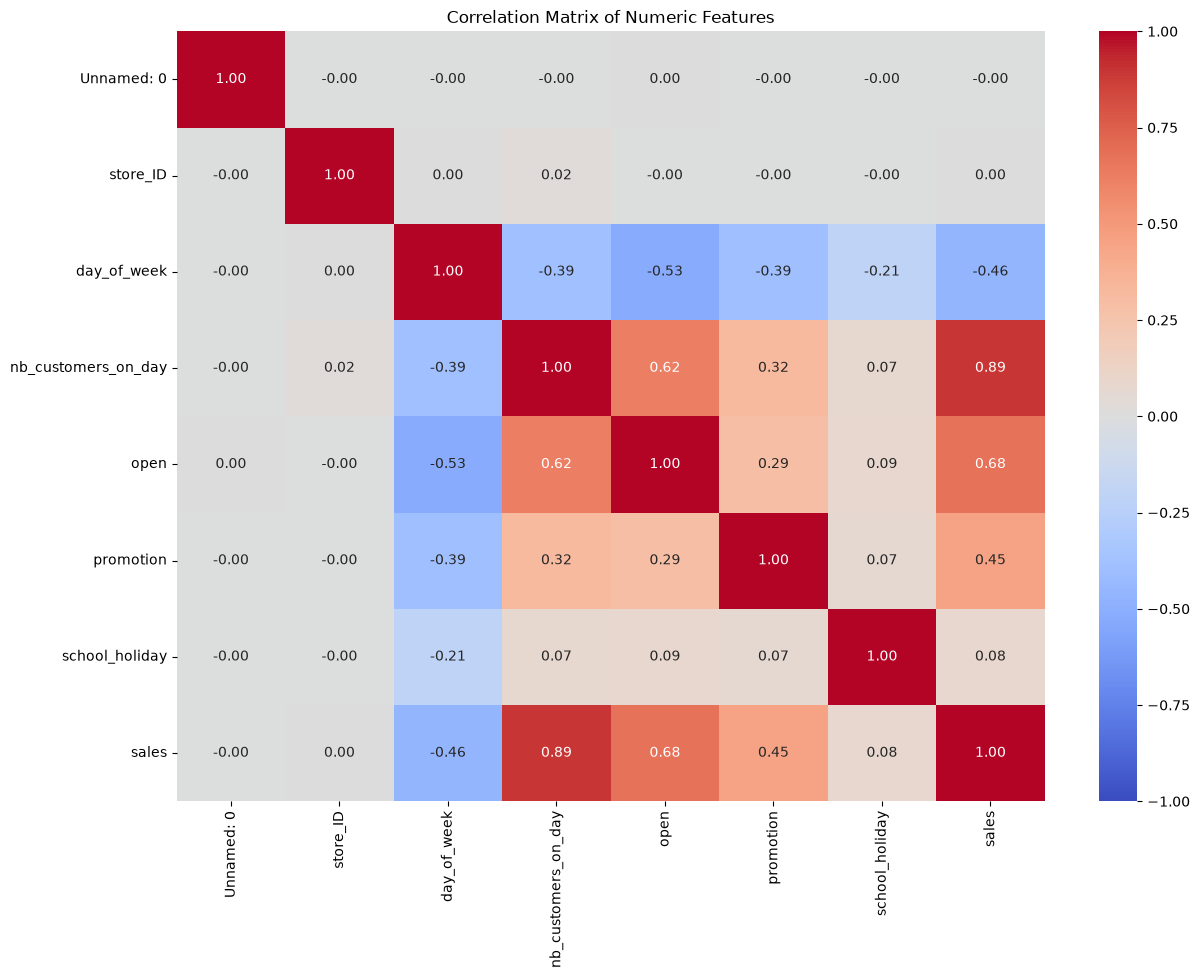

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# Select numeric columns
numeric_df = sales.select_dtypes(include=[np.number])

# Calculate pairwise linear correlation matrix
corr_matrix = numeric_df.corr()

# Visualize correlation matrix with seaborn heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

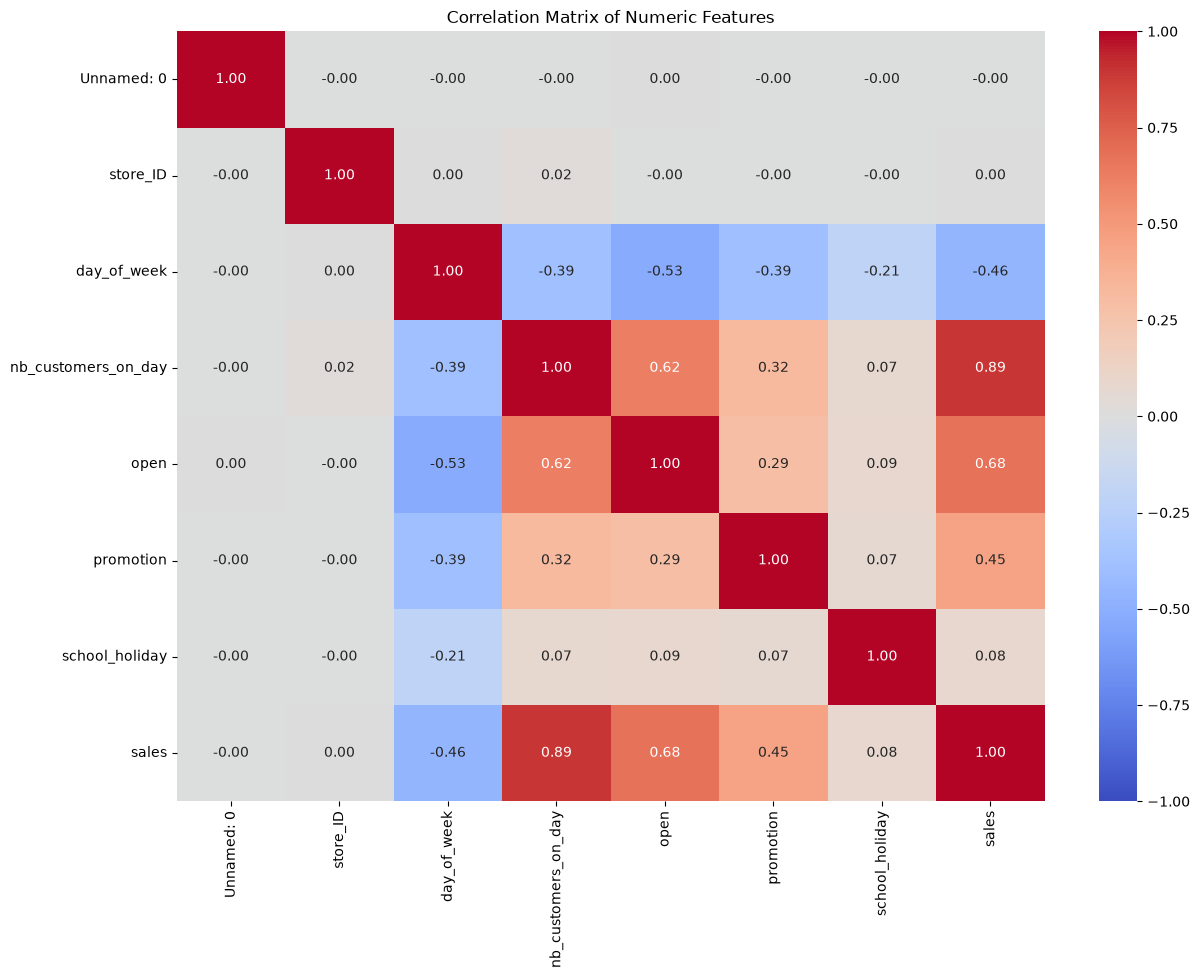

In [64]:
### 1. Code to Generate the Correlation Matrix & Heatmap


# Select numeric columns
numeric_df = sales.select_dtypes(include=[np.number])

# Calculate pairwise linear correlation matrix
corr_matrix = numeric_df.corr()

# Visualize correlation matrix with seaborn heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

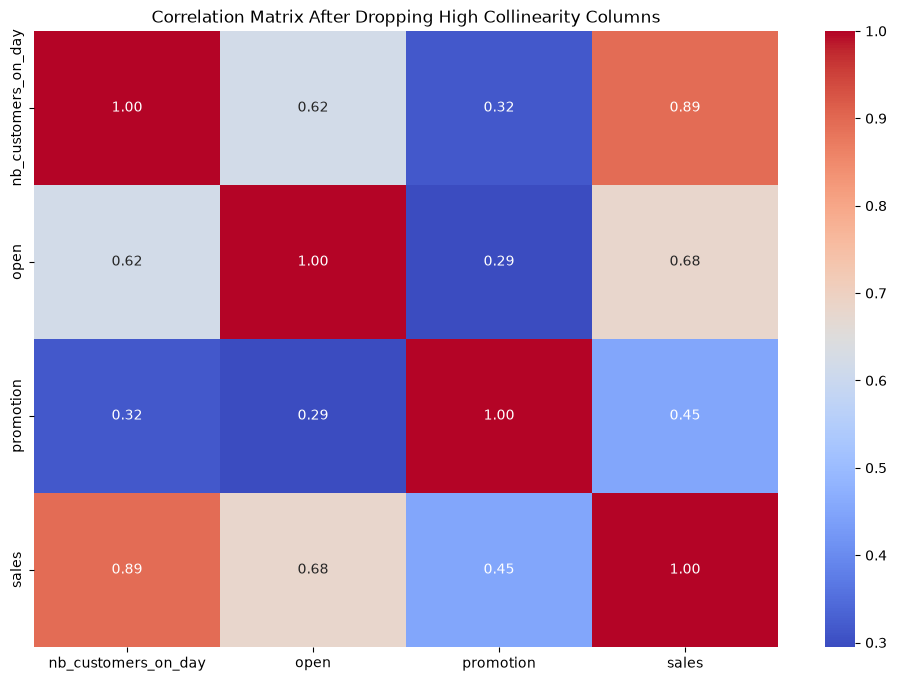

In [65]:
# Drop highly collinear redundant features (>0.90 correlation)
cols_to_drop = [
    "Unnamed: 0",
    "store_ID",
    "day_of_week",
    "school_holiday",
]
sales = sales.drop(columns=cols_to_drop)

# Re-evaluate correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(
    sales.select_dtypes(include=[np.number]).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)
plt.title("Correlation Matrix After Dropping High Collinearity Columns")
plt.show()

In [66]:
df = pd.read_csv("../data/sales.csv")
df.isna().sum()
print("\nMissing Values Count:")
print(df.isna().sum())


Missing Values Count:
Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64


What's the target variable : sales 
What features look important : number of customers , promotions , open 
Do you need to handle class imbalance : no imbalance 
Do you need to convert data to the correct data type : not needed so far 
Do you need to handle missing values and/or outliers : no all data present 